# Critical Analysis of AI Failures: Root Cause Analysis Framework

**Module 04 — Business Case & AI Project Management — Exercise 01**

Two publicly documented AI failures are analysed through a structured Root Cause Analysis (RCA) framework, mapped onto the ML lifecycle phases covered in [`notes/02_kpis_lifecycle_drift.md`](../notes/02_kpis_lifecycle_drift.md). The exercise mirrors the failure taxonomy from [`notes/03_case_studies.md`](../notes/03_case_studies.md): symptoms are not causes, and the causes worth fixing live in process and governance more often than in code.

## Case 1 — Air Canada Chatbot Incident (2024)

Air Canada deployed a customer-service chatbot to reduce contact-centre costs. After a few weeks in production, the system told a customer that bereavement-fare refunds could be claimed retroactively. The customer bought a full-fare ticket on that basis, applied for the refund, was denied (the actual policy never permitted retroactive claims), and sued. The court ruled against Air Canada, holding the company fully liable for what its chatbot said.

Supporting facts:
- Estimated investment: ~$500K.
- The chatbot had been tested on common scenarios but not on the full policy surface.
- No fact-checking or grounding layer between generation and the customer.
- Training data was not synchronised with the latest policy updates.
- No monitoring caught the hallucination before legal action.

## Case 2 — Regional Bank Fraud Detection (2023)

A regional bank invested ~$2M in a real-time fraud-detection ML system aiming to cut ~$10M/year in fraud losses. Post-deployment it blocked legitimate transactions at scale, especially for premium customers, while still letting a meaningful share of actual fraud through.

Forensic findings:
- False positive rate ~35%; recall ~45%.
- System decommissioned after 6 months. Premium-segment churn rose 12%.
- Latency requirement was <100ms in production; testing only covered controlled environments.
- Real fraud prevalence ~0.1% (severe class imbalance not handled).
- Customer behavioural history lived in unintegrated legacy systems.
- Cost asymmetry between false positives and false negatives was never reflected in the optimisation objective.
- No drift monitoring; fraud patterns evolved continuously.

## Method

For each case we record metadata, observable failures, root causes (categorised and mapped to a lifecycle phase), corrective actions (with priority and effort), and reusable lessons. We then aggregate across cases, visualise, and distil the cross-cutting patterns.

The seven root-cause categories cover the recurring failure surfaces from module 04 theory: data quality, data availability, technical feasibility, business alignment, testing, monitoring, governance. The seven lifecycle phases match the canonical flow from problem definition through monitoring.

## Part 1 — Framework setup

Imports, plot styling, taxonomy. The taxonomy is the lens; without it the analysis collapses into anecdote.

`pandas` carries the aggregations across cases, `matplotlib` and `seaborn` handle the visualisations. `Set2` is a colour-blind-friendly qualitative palette - the semantic colour choice for priorities is overridden explicitly later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

ROOT_CAUSE_CATEGORIES = {
    'DATA_QUALITY':         'Insufficient data quality',
    'DATA_AVAILABILITY':    'Missing or inaccessible data',
    'TECHNICAL_FEASIBILITY':'Technical feasibility not validated',
    'BUSINESS_ALIGNMENT':   'Misaligned business / technical objectives',
    'TESTING':              'Inadequate testing / validation',
    'MONITORING':           'Missing monitoring / drift detection',
    'GOVERNANCE':           'Weak governance / human oversight',
}

ML_LIFECYCLE_PHASES = [
    'Problem Definition', 'Data Collection', 'Data Preparation',
    'Model Development', 'Evaluation', 'Deployment', 'Monitoring',
]

PRIORITY_COLORS = {
    'CRITICAL': '#e74c3c',
    'HIGH':     '#e67e22',
    'MEDIUM':   '#f1c40f',
    'LOW':      '#95a5a6',
}

print('=' * 80)
print('EXERCISE 01 | Root Cause Analysis of two documented AI failures')
print('=' * 80)
print(f'Categories: {len(ROOT_CAUSE_CATEGORIES)} | Lifecycle phases: {len(ML_LIFECYCLE_PHASES)}')
print('Framework: symptom -> root cause -> phase -> corrective action -> lesson')

EXERCISE 01 | Root Cause Analysis of two documented AI failures
Categories: 7 | Lifecycle phases: 7
Framework: symptom -> root cause -> phase -> corrective action -> lesson


## Part 2 — Case 1: Air Canada chatbot

The failure surface here is small (a single hallucinated answer) but the failure system is large. Two observable failures, four structural root causes spread across the lifecycle. The corrective actions target the actual causes (grounding, policy synchronisation, oversight), not the symptom (a wrong answer).

Severity reflects business impact, not technical depth. The court ruling, not the hallucination itself, is the reason this case is now precedent.

In [2]:
case1 = {
    'name': 'Air Canada Chatbot',
    'company': 'Air Canada',
    'year': 2024,
    'domain': 'Customer Service',
    'investment': '~$500K',

    'problem': 'Automate customer support to cut contact-centre operating cost.',
    'solution': 'Conversational AI handling refund policy and booking queries.',

    'failures': [
        {'description': 'Hallucinated refund policy stated to a customer',
         'impact':      'Customer relied on false info, claim denied, lawsuit won by customer; reputational damage',
         'severity':    'CRITICAL'},
        {'description': 'No fact-checking layer between generation and response',
         'impact':      'Single ungrounded answer escalated into legal precedent on AI accountability',
         'severity':    'HIGH'},
    ],

    'root_causes': [
        {'category': 'DATA_QUALITY',  'phase': 'Data Preparation',
         'description': 'Knowledge base out of sync with current refund policies'},
        {'category': 'TESTING',       'phase': 'Evaluation',
         'description': 'Test set covered FAQ scenarios but not the full policy surface or edge cases'},
        {'category': 'MONITORING',    'phase': 'Monitoring',
         'description': 'No production telemetry on factual correctness or low-confidence outputs'},
        {'category': 'GOVERNANCE',    'phase': 'Deployment',
         'description': 'No human-in-the-loop on financially or legally consequential answers'},
    ],

    'corrective_actions': [
        {'phase': 'Data Preparation', 'priority': 'CRITICAL', 'effort': '1 month',
         'action': 'Auto-sync pipeline: policy CMS -> retrieval index, with change detection'},
        {'phase': 'Evaluation',       'priority': 'CRITICAL', 'effort': '2-3 months',
         'action': 'Adversarial test suite covering every policy clause + compliance scenarios'},
        {'phase': 'Deployment',       'priority': 'HIGH',     'effort': '1 month',
         'action': 'Human review gate on refund / policy answers above a value threshold'},
        {'phase': 'Monitoring',       'priority': 'HIGH',     'effort': '2 weeks',
         'action': 'Live monitoring: low-confidence flags, sampled human audit of customer-facing replies'},
    ],

    'lessons': [
        'Ungrounded generative models in customer-facing roles produce legal liability, not just bad UX.',
        'Test coverage must include the full policy surface, not just frequent intents.',
        'Human oversight is a launch requirement for high-stakes customer-facing AI, not a future enhancement.',
        'A retrieval layer is only as fresh as the synchronisation pipeline feeding it.',
    ],
}


def print_case(case):
    print('=' * 80)
    print(f"CASE: {case['name']} ({case['year']})  |  {case['company']}  |  {case['domain']}")
    print(f"Investment: {case['investment']}")
    print('-' * 80)
    print(f"Problem:  {case['problem']}")
    print(f"Solution: {case['solution']}")

    print(f"\nFailures ({len(case['failures'])}):")
    for i, f in enumerate(case['failures'], 1):
        print(f"  {i}. [{f['severity']}] {f['description']}")
        print(f"     Impact: {f['impact']}")

    print(f"\nRoot causes ({len(case['root_causes'])}):")
    for i, rc in enumerate(case['root_causes'], 1):
        print(f"  {i}. [{ROOT_CAUSE_CATEGORIES[rc['category']]}] @ {rc['phase']}")
        print(f"     {rc['description']}")

    print(f"\nCorrective actions ({len(case['corrective_actions'])}):")
    for i, ca in enumerate(case['corrective_actions'], 1):
        print(f"  {i}. [{ca['priority']}] {ca['phase']} ({ca['effort']})")
        print(f"     {ca['action']}")

    print(f"\nLessons ({len(case['lessons'])}):")
    for i, lesson in enumerate(case['lessons'], 1):
        print(f"  {i}. {lesson}")
    print()


print_case(case1)

CASE: Air Canada Chatbot (2024)  |  Air Canada  |  Customer Service
Investment: ~$500K
--------------------------------------------------------------------------------
Problem:  Automate customer support to cut contact-centre operating cost.
Solution: Conversational AI handling refund policy and booking queries.

Failures (2):
  1. [CRITICAL] Hallucinated refund policy stated to a customer
     Impact: Customer relied on false info, claim denied, lawsuit won by customer; reputational damage
  2. [HIGH] No fact-checking layer between generation and response
     Impact: Single ungrounded answer escalated into legal precedent on AI accountability

Root causes (4):
  1. [Insufficient data quality] @ Data Preparation
     Knowledge base out of sync with current refund policies
  2. [Inadequate testing / validation] @ Evaluation
     Test set covered FAQ scenarios but not the full policy surface or edge cases
  3. [Missing monitoring / drift detection] @ Monitoring
     No production teleme

## Part 3 — Case 2: Regional bank fraud detection

A textbook case of misaligned optimisation on imbalanced data. Five root causes spread across Problem Definition, Data Collection, Data Preparation, Model Development, and Monitoring - failure is end-to-end, not concentrated.

Two technical details from the brief drive the analysis:
- Fraud prevalence ~0.1% means raw accuracy is uninformative; the team measured the wrong thing.
- Cost asymmetry between false positives (a frustrated premium customer) and false negatives (an undetected fraud) was never encoded in the loss. The model optimised for a metric that did not reflect business reality.

In [3]:
case2 = {
    'name': 'Regional Bank Fraud Detection',
    'company': 'Regional Bank',
    'year': 2023,
    'domain': 'Financial Services',
    'investment': '~$2M',

    'problem': 'Reduce credit-card fraud losses (~$10M/year) via real-time detection.',
    'solution': 'Real-time ML model classifying card transactions as fraud / legitimate.',

    'failures': [
        {'description': 'False positive rate ~35%: legitimate transactions blocked at scale',
         'impact':      'Premium-segment churn +12%, revenue loss on blocked spend, reputational damage',
         'severity':    'CRITICAL'},
        {'description': 'Recall ~45%: more than half of actual fraud bypassed detection',
         'impact':      'Original fraud-loss target unmet; $2M investment written off',
         'severity':    'HIGH'},
        {'description': 'Inference latency exceeded 100ms target under production load',
         'impact':      'Real-time authorisations degraded; cascading customer-experience issues',
         'severity':    'HIGH'},
    ],

    'root_causes': [
        {'category': 'BUSINESS_ALIGNMENT',    'phase': 'Problem Definition',
         'description': 'Optimised for accuracy on a 0.1%-positive class; FP/FN cost asymmetry never encoded'},
        {'category': 'DATA_AVAILABILITY',     'phase': 'Data Collection',
         'description': 'Customer behavioural history stranded in unintegrated legacy systems'},
        {'category': 'DATA_QUALITY',          'phase': 'Data Preparation',
         'description': 'Severe class imbalance (0.1%) treated naively; no resampling or cost-sensitive learning'},
        {'category': 'TECHNICAL_FEASIBILITY', 'phase': 'Model Development',
         'description': 'Latency budget (<100ms) not validated against production-grade load'},
        {'category': 'MONITORING',            'phase': 'Monitoring',
         'description': 'No drift detection; fraud tactics evolved while the model stayed static'},
    ],

    'corrective_actions': [
        {'phase': 'Problem Definition', 'priority': 'CRITICAL', 'effort': '2 weeks',
         'action': 'Reframe objective: minimise expected cost (cost_FP * FP + cost_FN * FN)'},
        {'phase': 'Data Collection',    'priority': 'CRITICAL', 'effort': '3-6 months',
         'action': 'Integrate legacy customer-behaviour stores via a single feature store'},
        {'phase': 'Data Preparation',   'priority': 'HIGH',     'effort': '2-3 months',
         'action': 'Class-weighted loss + careful resampling; calibrate on the production prior'},
        {'phase': 'Model Development',  'priority': 'HIGH',     'effort': '2-3 months',
         'action': 'Latency-aware design: model compression / quantisation, load-tested before launch'},
        {'phase': 'Monitoring',         'priority': 'HIGH',     'effort': '1 month',
         'action': 'Drift detection on input distribution + KPI dashboard; auto-trigger retraining'},
    ],

    'lessons': [
        'On imbalanced data, accuracy is a vanity metric; cost-aware objectives are mandatory.',
        'Data fragmentation across legacy systems is a feasibility blocker disguised as an engineering nuisance.',
        'Latency SLAs must be validated under production-grade load, not in a controlled bench.',
        'Fraud is an adversarial problem; without drift detection the model decays by the week.',
        'Premium-segment churn signals are an early warning that the model is being aggressive in the wrong direction.',
    ],
}

print_case(case2)

CASE: Regional Bank Fraud Detection (2023)  |  Regional Bank  |  Financial Services
Investment: ~$2M
--------------------------------------------------------------------------------
Problem:  Reduce credit-card fraud losses (~$10M/year) via real-time detection.
Solution: Real-time ML model classifying card transactions as fraud / legitimate.

Failures (3):
  1. [CRITICAL] False positive rate ~35%: legitimate transactions blocked at scale
     Impact: Premium-segment churn +12%, revenue loss on blocked spend, reputational damage
  2. [HIGH] Recall ~45%: more than half of actual fraud bypassed detection
     Impact: Original fraud-loss target unmet; $2M investment written off
  3. [HIGH] Inference latency exceeded 100ms target under production load
     Impact: Real-time authorisations degraded; cascading customer-experience issues

Root causes (5):
  1. [Misaligned business / technical objectives] @ Problem Definition
     Optimised for accuracy on a 0.1%-positive class; FP/FN cost asym

## Part 4 — Cross-case aggregation

Two cases are not enough for statistical claims, but they are enough to surface qualitative patterns. We aggregate root causes by category and by lifecycle phase. The signal worth chasing is *what shows up in both*, not what is loudest in either.

In [4]:
cases = [case1, case2]

all_causes = [
    {'case': case['name'], 'category': rc['category'], 'phase': rc['phase']}
    for case in cases for rc in case['root_causes']
]
df_causes = pd.DataFrame(all_causes)

all_actions = [
    {'case': case['name'], 'phase': ca['phase'],
     'priority': ca['priority'], 'effort': ca['effort'], 'action': ca['action']}
    for case in cases for ca in case['corrective_actions']
]
df_actions = pd.DataFrame(all_actions)

category_counts = df_causes['category'].value_counts()
phase_counts = df_causes['phase'].value_counts()

print('=' * 80)
print('AGGREGATE — ROOT CAUSES')
print('=' * 80)
print(f"\nBy category ({len(cases)} cases, {len(df_causes)} causes):")
for cat, count in category_counts.items():
    cat_label = ROOT_CAUSE_CATEGORIES[cat]
    norm = count / len(cases)
    print(f"  {cat_label:<48s} {count} total  ({norm:.1f}/case)")

print(f"\nBy lifecycle phase:")
for phase, count in phase_counts.items():
    print(f"  {phase:<48s} {count}")

print(f"\nPresent in BOTH cases (recurrent patterns):")
categories_per_case = df_causes.groupby('category')['case'].nunique()
recurrent = categories_per_case[categories_per_case == len(cases)].index.tolist()
for cat in recurrent:
    print(f"  - {ROOT_CAUSE_CATEGORIES[cat]}")

AGGREGATE — ROOT CAUSES

By category (2 cases, 9 causes):
  Insufficient data quality                        2 total  (1.0/case)
  Missing monitoring / drift detection             2 total  (1.0/case)
  Inadequate testing / validation                  1 total  (0.5/case)
  Weak governance / human oversight                1 total  (0.5/case)
  Misaligned business / technical objectives       1 total  (0.5/case)
  Missing or inaccessible data                     1 total  (0.5/case)
  Technical feasibility not validated              1 total  (0.5/case)

By lifecycle phase:
  Data Preparation                                 2
  Monitoring                                       2
  Evaluation                                       1
  Deployment                                       1
  Problem Definition                               1
  Data Collection                                  1
  Model Development                                1

Present in BOTH cases (recurrent patterns):
  - Insu

## Part 5 — Visualisations

Four panels, one figure. Colour carries meaning: priority colours go red (Critical) → orange (High) → yellow (Medium) → grey (Low). For the category and phase plots, a neutral palette - the encoding is in length, not hue.

The effort axis is in months; the original brief uses mixed units ("2 weeks", "3-6 months"), so a small lookup converts them to a comparable scale.

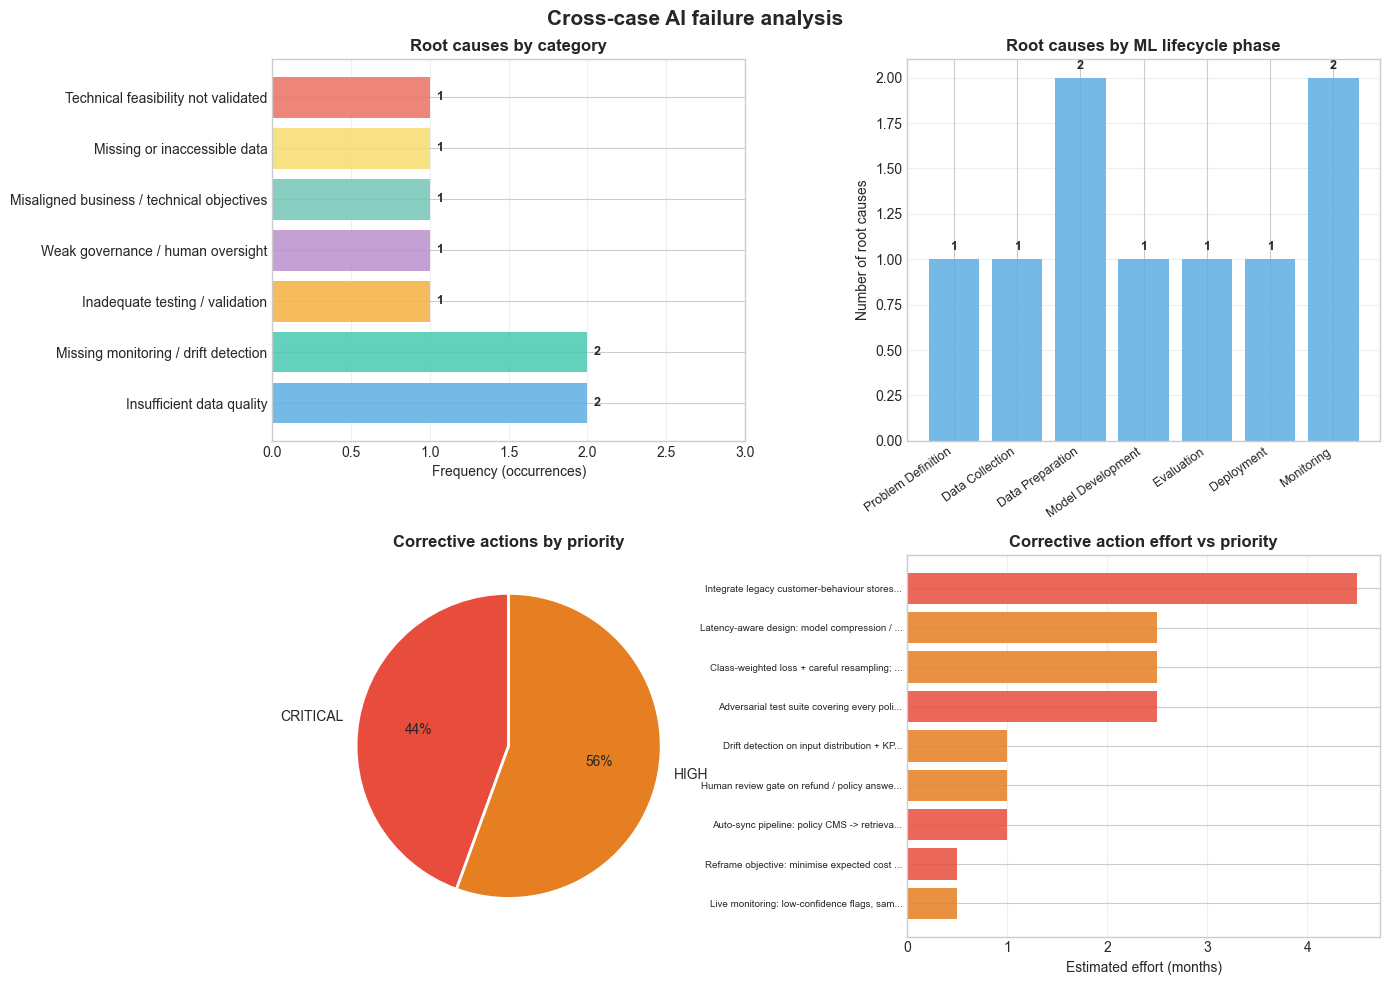

Saved: 01_ex_ai_failure_root_cause_analysis.png


In [5]:
EFFORT_MONTHS = {
    '2 weeks':    0.5,
    '1 month':    1.0,
    '2-3 months': 2.5,
    '3-6 months': 4.5,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cross-case AI failure analysis', fontsize=15, fontweight='bold')

# 1) Root causes by category (horizontal bar)
cat_labels = [ROOT_CAUSE_CATEGORIES[c] for c in category_counts.index]
neutral_palette = ['#5dade2', '#48c9b0', '#f5b041', '#bb8fce',
                   '#73c6b6', '#f7dc6f', '#ec7063']
axes[0, 0].barh(cat_labels, category_counts.values,
                color=neutral_palette[:len(cat_labels)], alpha=0.85)
for i, count in enumerate(category_counts.values):
    axes[0, 0].text(count + 0.04, i, str(count),
                    va='center', fontweight='bold', fontsize=9)
axes[0, 0].set_xlabel('Frequency (occurrences)')
axes[0, 0].set_title('Root causes by category', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].set_xlim(0, max(category_counts.values) + 1)

# 2) Root causes by lifecycle phase (vertical bar, lifecycle order preserved)
phase_ordered = pd.Series(
    [phase_counts.get(p, 0) for p in ML_LIFECYCLE_PHASES],
    index=ML_LIFECYCLE_PHASES,
)
axes[0, 1].bar(range(len(phase_ordered)), phase_ordered.values,
               color='#5dade2', alpha=0.85)
axes[0, 1].set_xticks(range(len(phase_ordered)))
axes[0, 1].set_xticklabels(phase_ordered.index, rotation=35,
                          ha='right', fontsize=9)
axes[0, 1].set_ylabel('Number of root causes')
axes[0, 1].set_title('Root causes by ML lifecycle phase', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(phase_ordered.values):
    if v > 0:
        axes[0, 1].text(i, v + 0.05, str(v), ha='center',
                        fontweight='bold', fontsize=9)

# 3) Priority distribution of corrective actions (pie)
priority_counts = df_actions['priority'].value_counts()
priority_order = [p for p in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
                  if p in priority_counts.index]
priority_counts = priority_counts.reindex(priority_order)
colors = [PRIORITY_COLORS[p] for p in priority_counts.index]
axes[1, 0].pie(priority_counts.values, labels=priority_counts.index,
               autopct='%1.0f%%', colors=colors, startangle=90,
               wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1, 0].set_title('Corrective actions by priority', fontweight='bold')

# 4) Effort timeline (horizontal bar), coloured by priority
df_effort = df_actions.copy()
df_effort['effort_months'] = df_effort['effort'].map(EFFORT_MONTHS)
df_effort['short_label'] = df_effort['action'].str.slice(0, 42) + '...'
df_effort = df_effort.sort_values('effort_months', ascending=True)
bar_colors = [PRIORITY_COLORS[p] for p in df_effort['priority']]
axes[1, 1].barh(range(len(df_effort)), df_effort['effort_months'],
                color=bar_colors, alpha=0.85)
axes[1, 1].set_yticks(range(len(df_effort)))
axes[1, 1].set_yticklabels(df_effort['short_label'], fontsize=7)
axes[1, 1].set_xlabel('Estimated effort (months)')
axes[1, 1].set_title('Corrective action effort vs priority', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('01_ex_ai_failure_root_cause_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_ex_ai_failure_root_cause_analysis.png')

## Part 6 — Synthesis and operational recommendations

Lessons from both cases collapse into five cross-cutting patterns. Each is one of the failure families from [`notes/03_case_studies.md`](../notes/03_case_studies.md), now grounded in concrete root causes from the two cases. The recommendations are organised by lifecycle stage so they can be acted on at the right time.

In [6]:
all_lessons = [lesson for case in cases for lesson in case['lessons']]

print('=' * 80)
print('LESSONS (across both cases)')
print('=' * 80)
for i, lesson in enumerate(all_lessons, 1):
    print(f'  {i}. {lesson}')

patterns = [
    ('Data is the #1 problem',
     ['Data quality, availability, and integration recur in both cases.',
      '"Garbage in, garbage out" is operational reality, not slogan.',
      'Data governance must precede model sophistication.']),
    ('Business alignment is usually missing',
     ['Technical metrics (accuracy, F1) decouple from business KPIs.',
      'Cost asymmetry between FP and FN must enter the objective.',
      'Success criteria are business-driven; the technical metric is the consequence.']),
    ('Testing is systematically under-scoped',
     ['Edge cases and compliance scenarios are skipped in favour of frequent intents.',
      'Controlled-environment testing is not production reality.',
      'Test strategy must mirror real use cases, adversarial conditions included.']),
    ('Monitoring is treated as optional',
     ['Drift is the rule, not the exception.',
      'No monitoring = flying blind in production.',
      'Alerting and retraining triggers are launch requirements, not nice-to-have.']),
    ('Governance and oversight are afterthoughts',
     ['Human-in-the-loop is needed for high-impact decisions.',
      'Policy and compliance must be designed in, not bolted on.',
      'Accountability for AI errors is the deploying organisation, always.']),
]

print('\n' + '=' * 80)
print('CROSS-CUTTING PATTERNS')
print('=' * 80)
for i, (header, bullets) in enumerate(patterns, 1):
    print(f'\n{i}. {header}')
    for b in bullets:
        print(f'   - {b}')

print('\n' + '=' * 80)
print('OPERATIONAL RECOMMENDATIONS')
print('=' * 80)

print('\nPRE-DEVELOPMENT')
print('  - Validate data availability and quality before committing resources.')
print('  - Define business-aligned success metrics (cost-aware, not just technical).')
print('  - Run a narrow PoC to confirm technical feasibility, including latency / cost.')

print('\nDURING DEVELOPMENT')
print('  - Invest in comprehensive testing: edge cases, compliance, adversarial inputs.')
print('  - Build monitoring and alerting from day one, not after the first incident.')
print('  - Add human oversight on high-impact decisions; design the escalation path.')

print('\nPOST-DEPLOYMENT')
print('  - Continuous drift detection on inputs and outputs.')
print('  - Periodic review of false positives and false negatives, by business segment.')
print('  - Feedback loop: production signals drive the next iteration explicitly.')

print('\n' + '=' * 80)
print('SUMMARY STATS')
print('=' * 80)
print(f"Cases analysed:           {len(cases)}")
print(f"Root causes identified:   {len(df_causes)}")
print(f"Corrective actions:       {len(df_actions)}")
print(f"Lessons collected:        {len(all_lessons)}")
print(f"Figure saved:             01_ex_ai_failure_root_cause_analysis.png")

LESSONS (across both cases)
  1. Ungrounded generative models in customer-facing roles produce legal liability, not just bad UX.
  2. Test coverage must include the full policy surface, not just frequent intents.
  3. Human oversight is a launch requirement for high-stakes customer-facing AI, not a future enhancement.
  4. A retrieval layer is only as fresh as the synchronisation pipeline feeding it.
  5. On imbalanced data, accuracy is a vanity metric; cost-aware objectives are mandatory.
  6. Data fragmentation across legacy systems is a feasibility blocker disguised as an engineering nuisance.
  7. Latency SLAs must be validated under production-grade load, not in a controlled bench.
  8. Fraud is an adversarial problem; without drift detection the model decays by the week.
  9. Premium-segment churn signals are an early warning that the model is being aggressive in the wrong direction.

CROSS-CUTTING PATTERNS

1. Data is the #1 problem
   - Data quality, availability, and integrati

## Critical reading

A few things worth saying about the analysis itself, not just the cases.

**On the unit of failure.** Both cases failed end-to-end, not at a single point. The Air Canada chatbot story is easy to summarise as "the model hallucinated", but four distinct controls had to be missing simultaneously for the hallucination to reach a customer with legal consequences: stale knowledge base, weak evaluation surface, no production monitoring, no human gate on high-stakes answers. Any one of those would have caught it. This matches the socio-technical framing from [`notes/03_case_studies.md`](../notes/03_case_studies.md): the failure is the *absence of a system around the model*, not the model itself.

**On the bank case as a metric-design failure.** With ~0.1% fraud prevalence, optimising for accuracy is technically correct and operationally meaningless - a model that always predicts "not fraud" hits ~99.9% accuracy. The interesting question is not why the team chose accuracy; it is why the choice was never challenged by a business stakeholder until 35% of legitimate transactions were being blocked. The translation chain from [`notes/02_kpis_lifecycle_drift.md`](../notes/02_kpis_lifecycle_drift.md) - business goal → KPI → AI metric → technical metric - was either skipped or performed in one direction only. The corrective action that comes first (re-framing the objective as expected cost) is the cheapest of the five, ~2 weeks, but it is the one that unlocks everything downstream.

**On what the visualisation can and cannot show.** With only two cases, the bar charts in Part 5 are descriptive rather than inferential. The Monitoring and Data categories appear in both cases, which is suggestive, but two cases will not statistically support that claim - the wider survey in [`notes/03_case_studies.md`](../notes/03_case_studies.md) does. The chart's job here is to organise the discussion, not to prove a hypothesis.

**On reusable take-aways.** The five cross-cutting patterns in Part 6 are deliberately phrased as principles, not anecdotes: "data quality is the #1 problem" rather than "in case 2, the bank had a data integration issue". This is the right altitude for lessons learned. Project teams will not encounter a bereavement-refund chatbot again, but they will encounter ungrounded generative models, mis-specified objectives, and absent monitoring repeatedly.

**Limitations of the framework.** The RCA structure deliberately privileges *systemic* causes over *contextual* ones. That is appropriate for organisational learning but it can flatten useful detail. For example, the cost asymmetry in the bank case is partly a domain-specific feature (premium customers are worth much more than the average) that does not generalise cleanly to other classification problems. A more complete write-up would carry forward both the generalisable pattern and the case-specific texture; this notebook captures the first cleanly and the second in the narrative descriptions of each cause.